#  Suicide Rate Analysis (Web Scraping + EDA)

In [1]:
# Install & Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import requests
from bs4 import BeautifulSoup
from io import StringIO

In [2]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_suicide_rate"

# Add a User-Agent header so Wikipedia doesn't block the request
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/147.0.0.0 Safari/537.36"
}
response = requests.get(url, headers=headers)

# Wrap the HTML text in StringIO
html_data = StringIO(response.text)

# Parse tables from the HTML content
tables = pd.read_html(html_data)
print(f"Number of tables found: {len(tables)}")

df = tables[1]
print(df.head())


Number of tables found: 7
    Country    Region  2021                  
    Country    Region   All  Male Female  M/F
0     World       NaN   9.2  12.4    5.9  2.1
1   Lesotho    Africa  28.7  41.4   16.6  2.5
2    Guyana  Americas  24.8  39.9   10.4  3.8
3  Eswatini    Africa  27.2  45.0   10.1  4.5
4  Kiribati   Oceania  17.5  31.0    4.8  6.5


In [3]:
# Inspect Dataset
df.head(10)

Country    Region  2021                  
                          Country    Region   All  Male Female  M/F
0                           World       NaN   9.2  12.4    5.9  2.1
1                         Lesotho    Africa  28.7  41.4   16.6  2.5
2                          Guyana  Americas  24.8  39.9   10.4  3.8
3                        Eswatini    Africa  27.2  45.0   10.1  4.5
4                        Kiribati   Oceania  17.5  31.0    4.8  6.5
5  Federated States of Micronesia   Oceania  19.8  31.1    8.6  3.6
6                        Suriname  Americas  22.3  30.5   14.0  2.2
7                        Zimbabwe    Africa  17.3  23.6   11.7  2.0
8                    South Africa    Africa  22.3  35.4    9.9  3.6
9                      Mozambique    Africa  10.6  15.6    6.0  2.6

In [4]:
df.tail()

Country    Region 2021                 
                              Country    Region  All Male Female  M/F
179                            Jordan      Asia  0.6  0.9    0.3  3.0
180  Saint Vincent and the Grenadines  Americas  0.4  0.8    0.0    -
181                           Grenada  Americas  1.3  1.9    0.7  2.7
182                          Barbados  Americas  3.5  6.3    1.0  6.3
183               Antigua and Barbuda  Americas  1.5  1.6    1.3  1.2

In [5]:
print("Shape:", df.shape)
df.info()

Shape: (184, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Country, Country)  184 non-null    object 
 1   (Region, Region)    183 non-null    object 
 2   (2021, All)         184 non-null    float64
 3   (2021, Male)        184 non-null    float64
 4   (2021, Female)      184 non-null    float64
 5   (2021, M/F)         184 non-null    object 
dtypes: float64(3), object(3)
memory usage: 8.8+ KB


## Clean the Data

Wikipedia tables usually contain footnotes like `[1]`.

In [6]:
# Remove citation markers like [1], [2], etc.
# Apply element-wise cleaning across all columns
df = df.apply(lambda col: col.map(lambda x: re.sub(r"\[\d+\]", "", str(x)).strip()))

In [7]:
df.tail()

Country    Region 2021                 
                              Country    Region  All Male Female  M/F
179                            Jordan      Asia  0.6  0.9    0.3  3.0
180  Saint Vincent and the Grenadines  Americas  0.4  0.8    0.0    -
181                           Grenada  Americas  1.3  1.9    0.7  2.7
182                          Barbados  Americas  3.5  6.3    1.0  6.3
183               Antigua and Barbuda  Americas  1.5  1.6    1.3  1.2

In [8]:
df.columns

MultiIndex([('Country', 'Country'),
            ( 'Region',  'Region'),
            (   '2021',     'All'),
            (   '2021',    'Male'),
            (   '2021',  'Female'),
            (   '2021',     'M/F')],
           )

In [9]:
# Flatten Multi-level Column names
df.columns = ['_'.join([str(c).strip().lower().replace(" ", "_") for c in col if c])
              if isinstance(col, tuple) else str(col).strip().lower().replace(" ", "_")
              for col in df.columns]

df.columns

Index(['country_country', 'region_region', '2021_all', '2021_male',
       '2021_female', '2021_m/f'],
      dtype='object')

In [10]:
df.columns = [
    "country",
    "region",
    "suicide_rate_all_2021",
    "suicide_rate_male_2021",
    "suicide_rate_female_2021",
    "male_female_ratio_2021"
]
df.columns

Index(['country', 'region', 'suicide_rate_all_2021', 'suicide_rate_male_2021',
       'suicide_rate_female_2021', 'male_female_ratio_2021'],
      dtype='object')

## Convert Suicide Rate Column to Numeric

Some values may still be text.

In [11]:
# Check columns
df.head()

,country,region,suicide_rate_all_2021,suicide_rate_male_2021,suicide_rate_female_2021,male_female_ratio_2021
0,World,nan,9.2,12.4,5.9,2.1
1,Lesotho,Africa,28.7,41.4,16.6,2.5
2,Guyana,Americas,24.8,39.9,10.4,3.8
3,Eswatini,Africa,27.2,45.0,10.1,4.5
4,Kiribati,Oceania,17.5,31.0,4.8,6.5


In [12]:
# Check columns
df.head()

# Convert numeric columns
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(",", "")

# Try converting columns to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   184 non-null    object 
 1   region                    184 non-null    object 
 2   suicide_rate_all_2021     184 non-null    float64
 3   suicide_rate_male_2021    184 non-null    float64
 4   suicide_rate_female_2021  184 non-null    float64
 5   male_female_ratio_2021    184 non-null    object 
dtypes: float64(3), object(3)
memory usage: 8.8+ KB


C:\Users\User\AppData\Local\Temp\ipykernel_21220\1412327373.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [13]:
# Check Missing Values
df.isnull().sum()

country                     0
region                      0
suicide_rate_all_2021       0
suicide_rate_male_2021      0
suicide_rate_female_2021    0
male_female_ratio_2021      0
dtype: int64

### 📊 EXPLORATORY DATA ANALYSIS (EDA)

In [14]:
# Summary Statistics
df.describe(include="all")

,country,region,suicide_rate_all_2021,suicide_rate_male_2021,suicide_rate_female_2021,male_female_ratio_2021
count,184,184,184.000000,184.000000,184.000000,184
unique,184,6,NaN,NaN,NaN,58
top,World,Africa,NaN,NaN,NaN,2.9
freq,1,54,NaN,NaN,NaN,16
mean,NaN,NaN,8.537500,13.084239,4.174457,NaN
std,NaN,NaN,5.867886,9.464020,2.977631,NaN
min,NaN,NaN,0.400000,0.800000,0.000000,NaN
25%,NaN,NaN,4.275000,6.275000,2.200000,NaN
50%,NaN,NaN,7.600000,11.100000,3.500000,NaN
75%,NaN,NaN,11.900000,17.750000,5.825000,NaN


Now assume the suicide rate column is something like `"suicide_rate"` or `"rate"`.

Let’s detect the best numeric column:

In [15]:
df.select_dtypes(include=np.number).columns

Index(['suicide_rate_all_2021', 'suicide_rate_male_2021',
       'suicide_rate_female_2021'],
      dtype='object')

Then save the first numeric column in a new variable

In [16]:
rate_col = df.select_dtypes(include=np.number).columns[0]
rate_col

'suicide_rate_all_2021'

In [17]:
# Now get top 10:
top10 = df.sort_values(by=rate_col, ascending=False).head(10)
top10

,country,region,suicide_rate_all_2021,suicide_rate_male_2021,suicide_rate_female_2021,male_female_ratio_2021
1,Lesotho,Africa,28.7,41.4,16.6,2.5
3,Eswatini,Africa,27.2,45.0,10.1,4.5
2,Guyana,Americas,24.8,39.9,10.4,3.8
16,Uruguay,Americas,24.8,39.9,10.5,3.8
6,Suriname,Americas,22.3,30.5,14.0,2.2
8,South Africa,Africa,22.3,35.4,9.9,3.6
15,Lithuania,Europe,22.1,36.7,9.2,4.0
11,Russia,Europe,21.4,36.7,8.1,4.5
19,Ukraine,Europe,21.2,37.7,6.9,5.4
12,South Korea,Asia,20.6,28.2,13.6,2.3


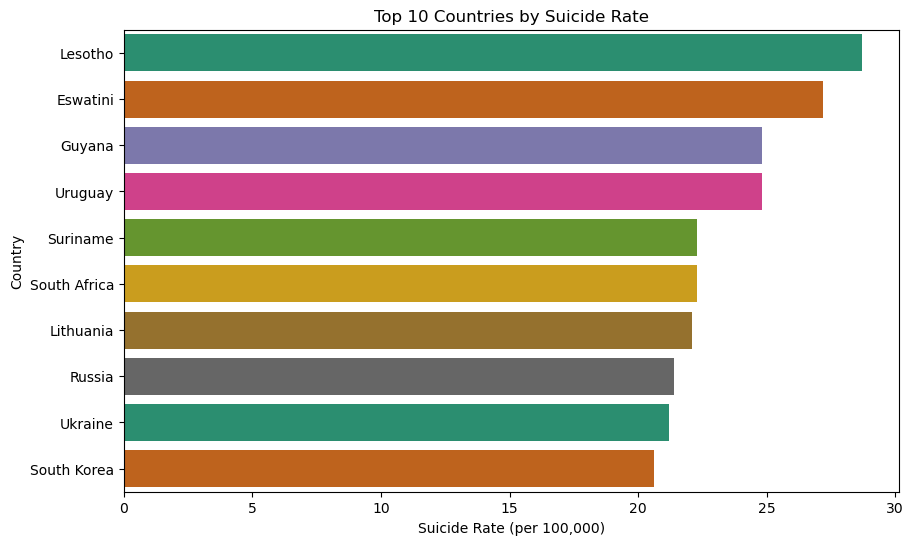

In [18]:
## ✅ 11. Visualization: Top 10 Countries (Bar Chart)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x=rate_col, y=df.columns[0], hue=df.columns[0], palette="Dark2", legend=False )
plt.title("Top 10 Countries by Suicide Rate")
plt.xlabel("Suicide Rate (per 100,000)")
plt.ylabel("Country")
plt.show()

In [19]:
# Bottom 10 Countries by Suicide Rate

bottom10 = df.sort_values(by=rate_col, ascending=True).head(10)
bottom10

,country,region,suicide_rate_all_2021,suicide_rate_male_2021,suicide_rate_female_2021,male_female_ratio_2021
180,Saint Vincent and the Grenadines,Americas,0.4,0.8,0.0,-
179,Jordan,Asia,0.6,0.9,0.3,3.0
177,Syria,Asia,0.6,0.9,0.3,3.3
158,Egypt,Africa,0.6,0.9,0.3,3.0
164,Lebanon,Asia,0.7,0.9,0.6,1.5
176,São Tomé and Príncipe,Africa,0.9,1.3,0.4,3.3
133,Saudi Arabia,Asia,0.9,1.1,0.7,1.6
149,Oman,Asia,0.9,1.4,0.2,7.0
171,Indonesia,Asia,1.2,1.5,0.9,1.7
181,Grenada,Americas,1.3,1.9,0.7,2.7


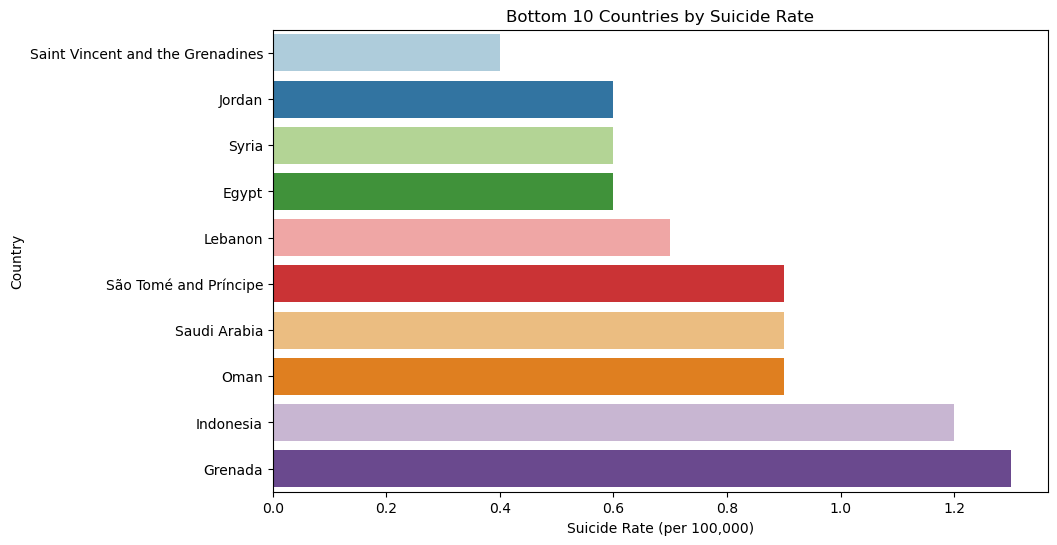

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=bottom10, x=rate_col, y=df.columns[0], hue=df.columns[0], palette="Paired", legend=False )
plt.title("Bottom 10 Countries by Suicide Rate")
plt.xlabel("Suicide Rate (per 100,000)")
plt.ylabel("Country")
plt.show()

## Distribution of Suicide Rates (Histogram)

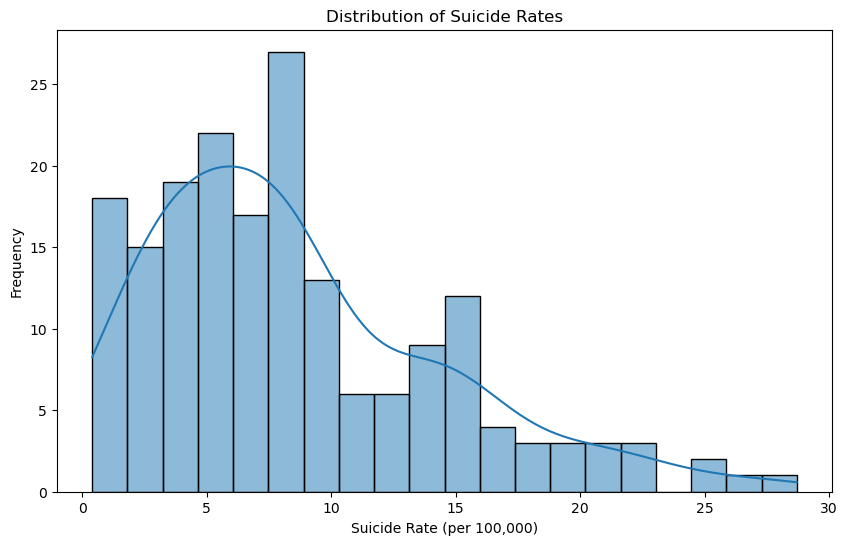

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df[rate_col], kde=True, bins=20)
plt.title("Distribution of Suicide Rates")
plt.xlabel("Suicide Rate (per 100,000)")
plt.ylabel("Frequency")
plt.show()

## Boxplot (Detect Outliers)

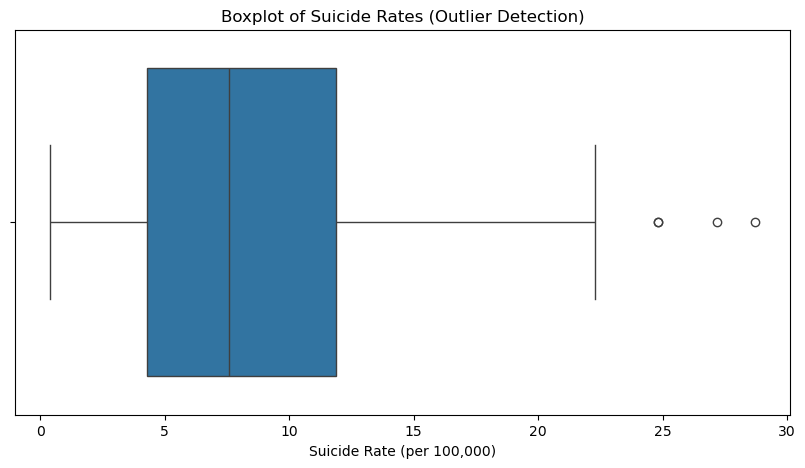

In [22]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df[rate_col])
plt.title("Boxplot of Suicide Rates (Outlier Detection)")
plt.xlabel("Suicide Rate (per 100,000)")
plt.show()

# 📌 INSIGHTS SECTION 

## ✅ 16. Key Insights

In [23]:
print("Key Findings:")
print(f"- The highest recorded suicide rate in this dataset is {df[rate_col].max():.2f} per 100,000.")
print(f"- The lowest recorded suicide rate is {df[rate_col].min():.2f} per 100,000.")
print(f"- The average suicide rate across all countries is {df[rate_col].mean():.2f} per 100,000.")
print(f"- The median suicide rate is {df[rate_col].median():.2f} per 100,000.")

Key Findings:
- The highest recorded suicide rate in this dataset is 28.70 per 100,000.
- The lowest recorded suicide rate is 0.40 per 100,000.
- The average suicide rate across all countries is 8.54 per 100,000.
- The median suicide rate is 7.60 per 100,000.


### Group Continents by Suicide Rate Risk Levels

In [25]:
continent_summary = df.groupby("region")[rate_col].mean().reset_index()

continent_summary = continent_summary.sort_values(by=rate_col, ascending=False)
continent_summary

,region,suicide_rate_all_2021
4,Oceania,12.440000
3,Europe,11.429545
5,nan,9.200000
0,Africa,7.816667
1,Americas,7.630303
2,Asia,6.202381


In [ ]:
def categorize_rate(rate):
    if rate < 5:
        return "Low"
    elif rate < 15:
        return "Medium"
    else:
        return "High"

df_clean["risk_category"] = df_clean[rate_col].apply(categorize_rate)
df_clean["risk_category"].value_counts()

In [ ]:
##  Visualize Risk Categories

plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="risk_category")
plt.title("Number of Countries by Suicide Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Count of Countries")
plt.show()